# Six-Month Forecast & Dashboard Export

Answers the project's core question directly: **which HX should be cleaned, and
when** — by linearly extrapolating each HX's fouling-deviation signal 182 days
(~6 months) forward from `Data/Time_To_Clean_Prediction.csv`, then exporting
everything the static HTML dashboard needs as JSON.

**No new detection/threshold logic is introduced here** — `Time_To_Clean_Prediction.csv`
(built in `07_time_to_clean_prediction.ipynb`) already contains a validated
per-HX deviation, threshold, and fouling rate; this notebook only projects that
trend forward and packages the result for the dashboard.

Sections:
1. Load `Time_To_Clean_Prediction.csv`, `hx_Q_cleaning_priority_v2.csv` (from `6b`),
   `Model_Comparison_Metrics.csv` (from `6a`)
2. 182-day linear extrapolation per HX
3. Final cleaning-recommendation table (HX, priority rank, projected trigger date)
4. Plot: 6-month forecast for top-priority HX
5. Export `dashboard/data/*.json`

## 0. Imports & Configuration

In [1]:
import json as jsonlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': 0.3})

DATA_DIR      = Path(r'C:\Desktop\Bangchak Internship 2026\Data')
REPO_ROOT     = Path(r'C:\Desktop\Bangchak Internship 2026\furnace-optimization')
OUT_DIR       = REPO_ROOT / 'outputs'
FIG_DIR       = REPO_ROOT / 'figures' / 'forecast_6mo'
DASHBOARD_DIR = REPO_ROOT / 'dashboard' / 'data'
FIG_DIR.mkdir(parents=True, exist_ok=True)
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

HORIZON_DAYS = 182   # ~6 months look-ahead

---
## 1. Load Inputs

In [2]:
ttc = pd.read_csv(DATA_DIR / 'Time_To_Clean_Prediction.csv')
priority_v2 = pd.read_csv(OUT_DIR / 'hx_Q_cleaning_priority_v2.csv', index_col=0)
model_metrics = pd.read_csv(OUT_DIR / 'Model_Comparison_Metrics.csv')

# Reference 'as of' date -- last timestamp in the underlying process data, same
# basis Time_To_Clean_Prediction.csv itself was built from.
last_date = pd.read_csv(DATA_DIR / 'Process_information_cleaned.csv',
                         index_col='Timestamp', parse_dates=True).index.max()

print(f'Time_To_Clean_Prediction.csv: {ttc.shape[0]} HX rows')
print(f'hx_Q_cleaning_priority_v2.csv: {priority_v2.shape[0]} HX rows')
print(f'As-of date: {last_date.date()}')
ttc.head()

Time_To_Clean_Prediction.csv: 15 HX rows
hx_Q_cleaning_priority_v2.csv: 14 HX rows
As-of date: 2026-07-01


,HX,effort_tier,current_deviation,threshold,threshold_source,threshold_confidence,rate_degC_per_day,rate_source,days_to_threshold,beyond_horizon,projected_need_by_date,at_risk_before_tam
0,E101EF,ONLINE_FULL,3851.174511,2847.804341,own_history,medium,3.395729,current_run,0.0,False,2026-07-01 00:00:00.000000000,False
1,E103AB,TAM_ONLY,1241.736508,515.857144,own_history,high,1.944337,current_run,0.0,False,2026-07-01 00:00:00.000000000,True
2,E109AB,TAM_ONLY,464.905336,203.563570,own_history,high,2.936283,current_run,0.0,False,2026-07-01 00:00:00.000000000,True
3,E104,ONLINE_FULL,2307.680007,613.272361,own_history,high,4.125196,current_run,0.0,False,2026-07-01 00:00:00.000000000,False
4,E110ABC,ONLINE_FULL,2369.806592,1243.306130,own_history,medium,2.959877,current_run,0.0,False,2026-07-01 00:00:00.000000000,False


---
## 2. 182-Day Linear Extrapolation per HX

`projected_deviation(t) = current_deviation + rate_degC_per_day * t`

Only HX with a **positive** fouling rate (deviation growing) can cross their
threshold going forward; HX with a flat/negative rate are marked
`beyond_horizon` (consistent with the convention already used in
`Time_To_Clean_Prediction.csv` / `07_time_to_clean_prediction.ipynb`).

In [3]:
forecast_rows = []
forecast_series = {}

for _, row in ttc.iterrows():
    hx = row['HX']
    current_dev = row['current_deviation']
    threshold   = row['threshold']
    rate        = row['rate_degC_per_day']

    days = np.arange(0, HORIZON_DAYS + 1)
    dates = [last_date + pd.Timedelta(days=int(d)) for d in days]
    projected = current_dev + rate * days

    if current_dev >= threshold:
        # Already past trigger as of the as-of date -- due now, not a future projection.
        days_to_cross = 0.0
    elif rate > 0:
        days_to_cross = (threshold - current_dev) / rate
    else:
        days_to_cross = np.nan

    if pd.notna(days_to_cross) and 0 <= days_to_cross <= HORIZON_DAYS:
        trigger_date = last_date + pd.Timedelta(days=float(days_to_cross))
        within_horizon = True
    else:
        trigger_date = pd.NaT
        within_horizon = False

    forecast_series[hx] = {
        'dates': [d.strftime('%Y-%m-%d') for d in dates],
        'projected_deviation': [round(float(v), 3) for v in projected],
        'threshold': float(threshold),
        'current_deviation': float(current_dev),
    }

    forecast_rows.append({
        'HX'                  : hx,
        'effort_tier'         : row['effort_tier'],
        'current_deviation'   : round(current_dev, 3),
        'threshold'           : round(threshold, 3),
        'rate_degC_per_day'   : round(rate, 5),
        'days_to_threshold_6mo': round(days_to_cross, 1) if pd.notna(days_to_cross) else np.nan,
        'projected_clean_date': trigger_date.date().isoformat() if within_horizon else None,
        'at_risk_within_6mo'  : bool(within_horizon or row['days_to_threshold'] == 0),
    })

forecast_df = pd.DataFrame(forecast_rows).sort_values('days_to_threshold_6mo', na_position='last')
print(f'{int(forecast_df["at_risk_within_6mo"].sum())} of {len(forecast_df)} HX projected to need cleaning within 6 months')
forecast_df

9 of 15 HX projected to need cleaning within 6 months


,HX,effort_tier,current_deviation,threshold,rate_degC_per_day,days_to_threshold_6mo,projected_clean_date,at_risk_within_6mo
0,E101EF,ONLINE_FULL,3851.175,2847.804,3.39573,0.0,2026-07-01,True
1,E103AB,TAM_ONLY,1241.737,515.857,1.94434,0.0,2026-07-01,True
2,E109AB,TAM_ONLY,464.905,203.564,2.93628,0.0,2026-07-01,True
3,E104,ONLINE_FULL,2307.680,613.272,4.12520,0.0,2026-07-01,True
4,E110ABC,ONLINE_FULL,2369.807,1243.306,2.95988,0.0,2026-07-01,True
5,E112AB,ONLINE_FULL,2354.924,940.663,0.07703,0.0,2026-07-01,True
6,E113A,SWAP_CAPABLE,2035.841,1609.212,18.76610,0.0,2026-07-01,True
7,E102,ONLINE_FULL,29.981,87.801,0.87881,65.8,2026-09-04,True
8,E107AB,TAM_ONLY,125.293,288.859,1.19726,136.6,2026-11-14,True
9,E101CD,ONLINE_PARTIAL,76.447,466.572,0.73043,534.1,None,False


---
## 3. Final Cleaning-Recommendation Table

Combines the SHAP-based priority ranking (`6b`) with the 6-month forecast
(section 2) — this is the direct answer to "which HX, and when."

In [4]:
recommendation = priority_v2[['priority_score', 'cit_shap_importance', 'Q_fouling_rate_abs',
                               'recommended_action']].copy()
recommendation['priority_rank'] = recommendation['priority_score'].rank(ascending=False).astype(int)

fc_indexed = forecast_df.set_index('HX')
recommendation = recommendation.join(
    fc_indexed[['effort_tier', 'projected_clean_date', 'at_risk_within_6mo', 'days_to_threshold_6mo']]
)
recommendation = recommendation.sort_values('priority_rank')

out_path = OUT_DIR / 'Cleaning_Recommendation_Final.csv'
recommendation.to_csv(out_path)
print(f'Saved -> {out_path}')
recommendation.round(3)

Saved -> C:\Desktop\Bangchak Internship 2026\furnace-optimization\outputs\Cleaning_Recommendation_Final.csv


,priority_score,cit_shap_importance,Q_fouling_rate_abs,recommended_action,priority_rank,effort_tier,projected_clean_date,at_risk_within_6mo,days_to_threshold_6mo
HX,,,,,,,,,
E113A,1.000,0.574,5.305,Clean now (past trigger),1,SWAP_CAPABLE,2026-07-01,True,0.0
E112AB,0.929,0.368,1.079,Stable / monitor,2,ONLINE_FULL,2026-07-01,True,0.0
E101AB,0.857,0.228,0.532,Clean now (past trigger),3,ONLINE_FULL,None,False,NaN
E104,0.786,0.356,0.361,Clean now (past trigger),4,ONLINE_FULL,2026-07-01,True,0.0
E109AB,0.714,0.102,3.431,Clean now (past trigger),5,TAM_ONLY,2026-07-01,True,0.0
E108AB,0.643,0.096,0.000,Clean now (past trigger),6,ONLINE_FULL,None,False,NaN
E110ABC,0.571,0.146,0.000,Clean now (past trigger),7,ONLINE_FULL,2026-07-01,True,0.0
E101CD,0.500,0.075,0.467,Stable / monitor,8,ONLINE_PARTIAL,None,False,534.1
E111,0.429,0.268,1.074,Clean now (past trigger),9,ONLINE_FULL,None,False,627.0


In [5]:
print('='*70)
print('FINAL CLEANING RECOMMENDATIONS (priority rank + 6-month forecast)')
print('='*70)
for hx, row in recommendation.head(8).iterrows():
    when = row['projected_clean_date'] if pd.notna(row['projected_clean_date']) else row['recommended_action']
    print(f"  #{int(row['priority_rank'])}  {hx:<10}  priority={row['priority_score']:.3f}  "
          f"effort={row['effort_tier']:<26}  clean by: {when}")
print('='*70)

FINAL CLEANING RECOMMENDATIONS (priority rank + 6-month forecast)
  #1  E113A       priority=1.000  effort=SWAP_CAPABLE                clean by: 2026-07-01
  #2  E112AB      priority=0.929  effort=ONLINE_FULL                 clean by: 2026-07-01
  #3  E101AB      priority=0.857  effort=ONLINE_FULL                 clean by: Clean now (past trigger)
  #4  E104        priority=0.786  effort=ONLINE_FULL                 clean by: 2026-07-01
  #5  E109AB      priority=0.714  effort=TAM_ONLY                    clean by: 2026-07-01
  #6  E108AB      priority=0.643  effort=ONLINE_FULL                 clean by: Clean now (past trigger)
  #7  E110ABC     priority=0.571  effort=ONLINE_FULL                 clean by: 2026-07-01
  #8  E101CD      priority=0.500  effort=ONLINE_PARTIAL              clean by: Stable / monitor


---
## 4. Plot: 6-Month Forecast for Top-Priority HX

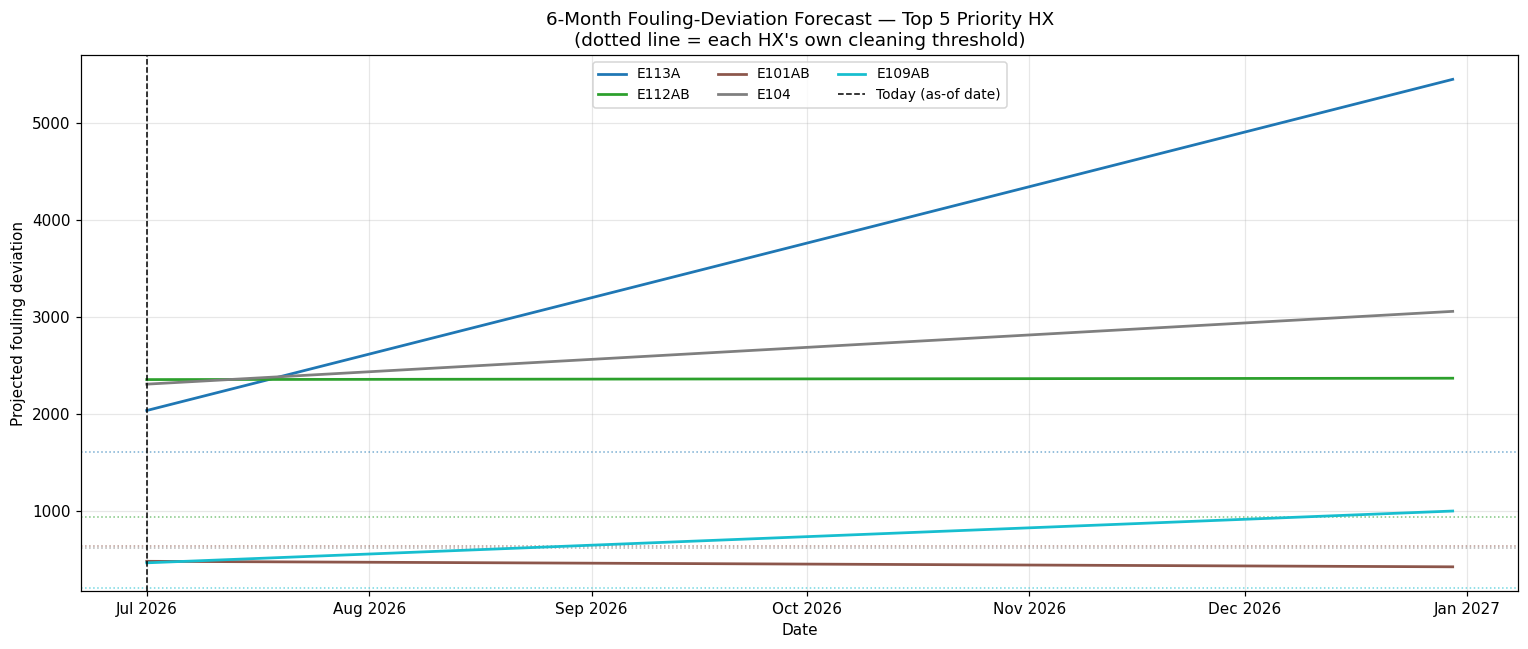

In [6]:
top5 = recommendation.head(5).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(top5)))
for hx, color in zip(top5, colors):
    fc = forecast_series[hx]
    dates = pd.to_datetime(fc['dates'])
    ax.plot(dates, fc['projected_deviation'], lw=1.8, color=color, label=f'{hx}')
    ax.axhline(fc['threshold'], color=color, ls=':', lw=1, alpha=0.6)

ax.axvline(last_date, color='black', ls='--', lw=1, label='Today (as-of date)')
ax.set_ylabel('Projected fouling deviation')
ax.set_xlabel('Date')
ax.set_title('6-Month Fouling-Deviation Forecast — Top 5 Priority HX\n(dotted line = each HX\'s own cleaning threshold)')
ax.legend(ncol=3, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'six_month_forecast_top5.png', dpi=110, bbox_inches='tight')
plt.show()

---
## 5. Export Dashboard Data (`dashboard/data/*.json`)

In [7]:
# hx_ranking.json -- SHAP-based cleaning priority table
hx_ranking = priority_v2.reset_index().rename(columns={'index': 'HX'})
hx_ranking.columns = ['HX'] + list(hx_ranking.columns[1:])
hx_ranking_records = jsonlib.loads(hx_ranking.round(4).to_json(orient='records'))
with open(DASHBOARD_DIR / 'hx_ranking.json', 'w') as f:
    jsonlib.dump(hx_ranking_records, f, indent=2)

# forecast_6mo.json -- per-HX daily projected series
with open(DASHBOARD_DIR / 'forecast_6mo.json', 'w') as f:
    jsonlib.dump(forecast_series, f, indent=2)

# model_metrics.json -- XGBoost/RF/LSTM benchmark
model_metrics_records = jsonlib.loads(model_metrics.round(3).to_json(orient='records'))
with open(DASHBOARD_DIR / 'model_metrics.json', 'w') as f:
    jsonlib.dump(model_metrics_records, f, indent=2)

# cleaning_recommendations.json -- final synthesized table
reco_export = recommendation.reset_index().rename(columns={'index': 'HX'})
reco_records = jsonlib.loads(reco_export.round(4).to_json(orient='records'))
with open(DASHBOARD_DIR / 'cleaning_recommendations.json', 'w') as f:
    jsonlib.dump(reco_records, f, indent=2)

print('Exported dashboard data files:')
for f in sorted(DASHBOARD_DIR.glob('*.json')):
    print(' -', f.name, f'({f.stat().st_size:,} bytes)')

Exported dashboard data files:
 - clean_baseline_sandbox.json (1,552 bytes)
 - cleaning_history.json (60,264 bytes)
 - cleaning_logistics.json (10,280 bytes)
 - cleaning_plan.json (16,792 bytes)
 - cleaning_recommendations.json (4,947 bytes)
 - cleaning_schedule.json (13,126 bytes)
 - cleaning_schedule_v2.json (18,981 bytes)
 - cost_overrides.json (2 bytes)
 - drivers.json (1,623 bytes)
 - economics.json (6,007 bytes)
 - end_of_run.json (24,691 bytes)
 - evidence.json (7,718 bytes)
 - forecast_6mo.json (105,369 bytes)
 - hx_ranking.json (6,716 bytes)
 - hx_timeseries.json (972,833 bytes)
 - model_metrics.json (698 bytes)
 - opt_params.json (25 bytes)
 - pfd_topology.json (21,245 bytes)
 - propagation_models.json (38,934 bytes)
 - reliability.json (61,876 bytes)
 - rul.json (3,492 bytes)
 - tam_analysis.json (22,246 bytes)


In [8]:
# Validate every exported file is well-formed JSON
for f in sorted(DASHBOARD_DIR.glob('*.json')):
    with open(f) as fh:
        obj = jsonlib.load(fh)
    n = len(obj) if isinstance(obj, list) else len(obj.keys())
    print(f'{f.name}: OK ({n} top-level entries)')

clean_baseline_sandbox.json: OK (4 top-level entries)
cleaning_history.json: OK (3 top-level entries)
cleaning_logistics.json: OK (5 top-level entries)
cleaning_plan.json: OK (11 top-level entries)
cleaning_recommendations.json: OK (14 top-level entries)
cleaning_schedule.json: OK (10 top-level entries)
cleaning_schedule_v2.json: OK (19 top-level entries)
cost_overrides.json: OK (0 top-level entries)
drivers.json: OK (7 top-level entries)
economics.json: OK (11 top-level entries)
end_of_run.json: OK (4 top-level entries)
evidence.json: OK (8 top-level entries)
forecast_6mo.json: OK (15 top-level entries)
hx_ranking.json: OK (14 top-level entries)
hx_timeseries.json: OK (16 top-level entries)
model_metrics.json: OK (4 top-level entries)
opt_params.json: OK (1 top-level entries)
pfd_topology.json: OK (11 top-level entries)
propagation_models.json: OK (5 top-level entries)
reliability.json: OK (16 top-level entries)
rul.json: OK (15 top-level entries)
tam_analysis.json: OK (12 top-level e

---
## Summary

- **6-month forecast**: linear extrapolation of each HX's validated fouling
  deviation rate against its own cleaning threshold, 182 days forward from the
  latest process data.
- **Final recommendation**: `outputs/Cleaning_Recommendation_Final.csv` merges
  SHAP-based priority rank (`6b`) with the projected cleaning date (this notebook)
  — this is the direct "which HX, and when" answer.
- **Dashboard data**: `dashboard/data/hx_ranking.json`, `forecast_6mo.json`,
  `model_metrics.json`, `cleaning_recommendations.json` — consumed by
  `dashboard/index.html`.